#**Knowledge Distillation for CNN Model Compression on CIFAR-10**

##**Objective**

Train a large teacher network and transfer knowledge to smaller student networks using knowledge distillation. Compare model size and accuracy trade-offs.

#**1. Environment Setup and Imports**

Import required libraries and configure GPU device.

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

import torchvision.transforms as transforms
from torchvision import models

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


#**2. Data Preparation**

Load the CIFAR-10 dataset and apply data augmentation techniques such as random cropping and horizontal flipping.

In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

trainloader = DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

classes = trainset.classes

print(classes)

100%|██████████| 170M/170M [00:03<00:00, 42.7MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


#**3. Teacher Network (ResNet18)**

Use a pretrained ResNet18 model as the teacher network and fine-tune it for CIFAR-10 classification.

In [3]:
teacher = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

teacher.fc = nn.Linear(
    teacher.fc.in_features,
    10
)

teacher = teacher.to(device)

print("Pretrained ResNet18 loaded")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


Pretrained ResNet18 loaded


#**4. Student Network**

Implement a lightweight CNN student model for comparison against the teacher network.

In [4]:
class StudentCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x


student = StudentCNN().to(device)

print(student)

StudentCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)

#**5. Model Training and Evaluation Utilities**

Define reusable functions for model training, evaluation, and parameter counting.

In [5]:
def train_model(model, epochs):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    losses = []

    model.train()

    for epoch in range(epochs):

        running_loss = 0

        loop = tqdm(trainloader)

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)

        losses.append(epoch_loss)

        scheduler.step()

        print(
            f"Epoch {epoch+1}/{epochs} Loss={epoch_loss:.4f}"
        )

    return losses

In [6]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    preds = []
    labels_all = []

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            preds.extend(predicted.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = 100 * correct / total

    return acc, preds, labels_all

In [ ]:
def count_params(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )

#**6. Teacher Training**

Train the ResNet18 teacher for 100 epochs using Adam optimizer, weight decay, and cosine learning rate scheduling.

In [7]:
teacher_losses = train_model(
    teacher,
    epochs=100
)

teacher_acc, teacher_preds, teacher_labels = evaluate(
    teacher
)

print(
    f"Teacher Accuracy: {teacher_acc:.2f}%"
)

torch.save(
    teacher.state_dict(),
    "/content/teacher_v2.pth"
)

100%|██████████| 391/391 [00:26<00:00, 14.99it/s]


Epoch 1/100 Loss=1.0369


100%|██████████| 391/391 [00:27<00:00, 14.27it/s]


Epoch 2/100 Loss=0.7353


100%|██████████| 391/391 [00:26<00:00, 14.66it/s]


...

100%|██████████| 391/391 [00:25<00:00, 15.53it/s]


Epoch 99/100 Loss=0.0251


100%|██████████| 391/391 [00:25<00:00, 15.52it/s]

Epoch 100/100 Loss=0.0246


Teacher Accuracy: 88.50%


#**7. Student Training**

Train the baseline student CNN and compare its performance with the teacher network.

In [8]:
student_losses = train_model(
    student,
    epochs=45
)

student_acc, student_preds, student_labels = evaluate(
    student
)

print(
    f"Student Accuracy: {student_acc:.2f}%"
)

torch.save(
    student.state_dict(),
    "/content/student.pth"
)

100%|██████████| 391/391 [00:18<00:00, 20.94it/s]


Epoch 1/45 Loss=1.4266


100%|██████████| 391/391 [00:17<00:00, 22.84it/s]


Epoch 2/45 Loss=1.0424


100%|██████████| 391/391 [00:17<00:00, 22.08it/s]


...

Epoch 44/45 Loss=0.2355


100%|██████████| 391/391 [00:18<00:00, 21.07it/s]

Epoch 45/45 Loss=0.2316


Student Accuracy: 87.79%


RuntimeError: Parent directory /content/drive/MyDrive does not exist.

#**8. Compressed Student Architecture**

Create a highly compressed student model using global average pooling to significantly reduce parameter count.

In [10]:
class CompressedStudentCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
compressed_student = CompressedStudentCNN().to(device)

compressed_losses = train_model(
    compressed_student,
    epochs=45
)

compressed_acc, compressed_preds, compressed_labels = evaluate(
    compressed_student
)

print(
    f"Compressed Student Accuracy: {compressed_acc:.2f}%"
)

torch.save(
    compressed_student.state_dict(),
    "/content/compressed_student.pth"
)

100%|██████████| 391/391 [00:19<00:00, 20.32it/s]


Epoch 1/45 Loss=1.4419


100%|██████████| 391/391 [00:19<00:00, 20.08it/s]


Epoch 2/45 Loss=1.0796


100%|██████████| 391/391 [00:25<00:00, 15.53it/s]


...

Epoch 44/45 Loss=0.3140


100%|██████████| 391/391 [00:19<00:00, 20.09it/s]

Epoch 45/45 Loss=0.3156


Compressed Student Accuracy: 83.53%


RuntimeError: Parent directory /content/drive/MyDrive does not exist.

In [13]:
print("\nPARAMETER COMPARISON")
print("-"*40)

print(
    f"Teacher: {count_params(teacher):,}"
)

print(
    f"Student: {count_params(student):,}"
)

print(
    f"Compressed Student: {count_params(compressed_student):,}"
)

print(
    f"Compressed Accuracy: {compressed_acc:.2f}%"
)

compression_ratio = (
    count_params(student)
    / count_params(compressed_student)
)

print(f"Compression Ratio: {compression_ratio:.2f}x")


PARAMETER COMPARISON
----------------------------------------
Teacher: 11,181,642
Student: 2,193,674
Compressed Student: 94,986
Compressed Accuracy: 83.53%
Compression Ratio: 23.09x


In [14]:
class DistillationLoss(nn.Module):

    def __init__(self,
                 temperature=4,
                 alpha=0.5):

        super().__init__()

        self.temperature = temperature
        self.alpha = alpha

        self.ce = nn.CrossEntropyLoss()
        self.kl = nn.KLDivLoss(
            reduction='batchmean'
        )

    def forward(
        self,
        student_logits,
        teacher_logits,
        labels
    ):

        soft_student = nn.functional.log_softmax(
            student_logits/self.temperature,
            dim=1
        )

        soft_teacher = nn.functional.softmax(
            teacher_logits/self.temperature,
            dim=1
        )

        distill_loss = self.kl(
            soft_student,
            soft_teacher
        )

        ce_loss = self.ce(
            student_logits,
            labels
        )

        return (
            self.alpha*ce_loss +
            (1-self.alpha)*
            (self.temperature**2)*
            distill_loss
        )

#**9. Knowledge Distillation**

Transfer knowledge from the teacher network to the compressed student using soft targets and KL-divergence based distillation loss.

In [15]:
distilled_student = CompressedStudentCNN().to(device)

In [19]:
criterion = DistillationLoss(
    temperature=2,
    alpha=0.8
)

optimizer = optim.Adam(
    distilled_student.parameters(),
    lr=0.001
)

teacher.eval()

distill_losses = []

for epoch in range(60):

    distilled_student.train()

    running_loss = 0

    loop = tqdm(trainloader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(images)

        student_logits = distilled_student(images)

        loss = criterion(
            student_logits,
            teacher_logits,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)

    distill_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1} Loss={epoch_loss:.4f}"
    )

100%|██████████| 391/391 [00:19<00:00, 20.42it/s]


Epoch 1 Loss=0.6023


100%|██████████| 391/391 [00:19<00:00, 19.59it/s]


Epoch 2 Loss=0.5927


100%|██████████| 391/391 [00:19<00:00, 20.39it/s]


...

Epoch 58 Loss=0.4381


100%|██████████| 391/391 [00:19<00:00, 20.34it/s]


Epoch 59 Loss=0.4347


100%|██████████| 391/391 [00:20<00:00, 19.33it/s]

Epoch 60 Loss=0.4239


In [31]:
distill_acc, distill_preds, distill_labels = evaluate(
    distilled_student
)

print(
    f"Distilled Compressed Student Accuracy: {distill_acc:.2f}%"
)

torch.save(
    distilled_student.state_dict(),
    "/content/distilled_student.pth"
)

Distilled Compressed Student Accuracy: 83.48%


#**10. Results and Analysis**

Compare model accuracy, parameter counts, and compression ratios. Analyze the impact of model compression and knowledge distillation.

In [20]:
print("Teacher:", count_params(teacher))
print("Student:", count_params(student))
print("Distilled:", count_params(distilled_student))

Teacher: 11181642
Student: 2193674
Distilled: 94986


In [21]:
print("="*40)

print(
    f"Teacher Accuracy: {teacher_acc:.2f}%"
)

print(
    f"Student Accuracy: {student_acc:.2f}%"
)

print(
    f"Distilled Accuracy: {distill_acc:.2f}%"
)

print("="*40)

Teacher Accuracy: 88.50%
Student Accuracy: 87.79%
Distilled Accuracy: 82.00%


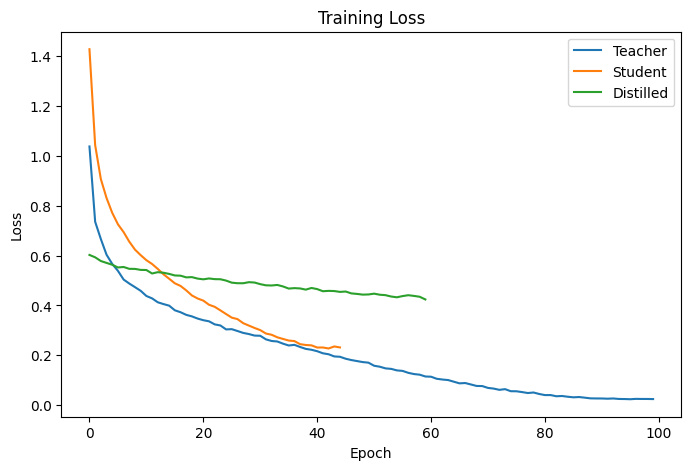

In [23]:
plt.figure(figsize=(8,5))

plt.plot(teacher_losses,label="Teacher")
plt.plot(student_losses,label="Student")
plt.plot(distill_losses,label="Distilled")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.title("Training Loss")

plt.savefig(
    "/content/loss_curve.png",
    bbox_inches="tight"
)

plt.show()

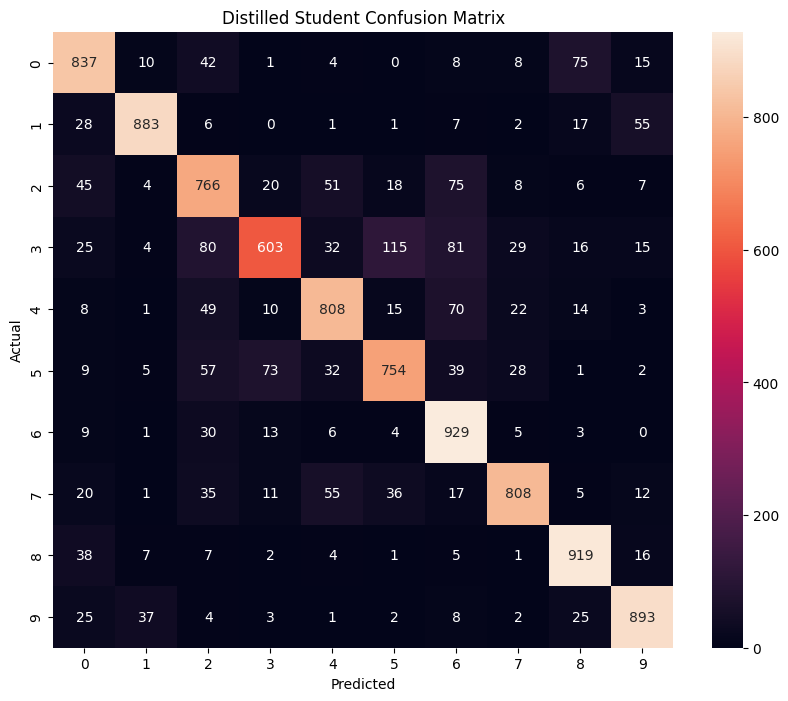

In [24]:
cm = confusion_matrix(
    distill_labels,
    distill_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Distilled Student Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "/content/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [30]:
print("\nFINAL RESULTS")
print("-"*80)

print(f"{'Model':<30}{'Accuracy':<15}{'Parameters':<15}")

print(f"{'Teacher':<30}{teacher_acc:.2f}%{'':<6}{count_params(teacher):,}")
print(f"{'Student':<30}{student_acc:.2f}%{'':<6}{count_params(student):,}")
print(f"{'Compressed Student':<30}{compressed_acc:.2f}%{'':<6}{count_params(compressed_student):,}")
print(f"{'Distilled Compressed Student':<30}{distill_acc:.2f}%{'':<6}{count_params(distilled_student):,}")


FINAL RESULTS
--------------------------------------------------------------------------------
Model                         Accuracy       Parameters     
Teacher                       88.50%      11,181,642
Student                       87.79%      2,193,674
Compressed Student            83.53%      94,986
Distilled Compressed Student  82.00%      94,986


# Key Findings

1. ResNet18 teacher achieved 88.50% accuracy on CIFAR-10.

2. The custom Student CNN achieved 87.79% accuracy while using approximately 5× fewer parameters than the teacher.

3. A compressed student architecture reduced parameter count from 2.19M to 94.9K parameters (23.09× reduction).

4. Knowledge distillation was applied to the compressed architecture. The distilled model achieved 83.48% accuracy, indicating that aggressive compression introduced a capacity bottleneck that limited the effectiveness of distillation.